In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import seaborn as sns
from scipy.stats import kurtosis
from scipy.stats import skew

In [403]:
# Step 1: Load the datasets
lbp_class_0 = pd.read_csv("dataset/features_subset_0_lbp.csv")
lbp_class_1 = pd.read_csv("dataset/features_subset_1_lbp.csv")


# Step 2: Add class labels to each dataset
lbp_class_0['target'] = 0  # Label for class 0
lbp_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
lbp_combined = pd.concat([lbp_class_0, lbp_class_1], ignore_index=True)


lbp_combined = lbp_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows

In [404]:
print(lbp_class_0.shape)
print(lbp_class_1.shape)

(89, 157)
(97, 216)


### lbp_combined has a lot of NaNs after concateantion (it has less features)

In [405]:
lbp_combined.fillna(0, inplace=True)

In [406]:
lbp_combined.shape

(186, 216)

In [407]:
# Step 1: Load the datasets
df_class_0 = pd.read_csv("dataset/graycomatrix_image_analysis_class_0.csv")
df_class_1 = pd.read_csv("dataset/graycomatrix_image_analysis_class_1.csv")


# Step 2: Add class labels to each dataset
df_class_0['target'] = 0  # Label for class 0
df_class_1['target'] = 1  # Label for class 1

# Step 3: Concatenate the datasets and shuffle
df_combined = pd.concat([df_class_0, df_class_1], ignore_index=True)
#df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle rows

df_combined = df_combined.sample(frac=1, random_state=142).reset_index(drop=True)  # Shuffle rows


In [381]:
df_combined.shape

(186, 32)

In [382]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 32 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        186 non-null    object 
 1   GLCM_Contrast     186 non-null    float64
 2   GLCM_Correlation  186 non-null    float64
 3   GLCM_Energy       186 non-null    float64
 4   GLCM_Homogeneity  186 non-null    float64
 5   LBP_0             186 non-null    float64
 6   LBP_1             186 non-null    float64
 7   LBP_2             186 non-null    float64
 8   LBP_3             186 non-null    float64
 9   LBP_4             186 non-null    float64
 10  LBP_5             186 non-null    float64
 11  LBP_6             186 non-null    float64
 12  LBP_7             186 non-null    float64
 13  LBP_8             186 non-null    float64
 14  LBP_9             186 non-null    float64
 15  LBP_10            186 non-null    float64
 16  LBP_11            186 non-null    float64
 1

### Now, I will extract the means, se, max and min of morhological features of all the objects in samle, and count as well

In [383]:
# Extract the sample IDs
sample_ids = lbp_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = lbp_combined[lbp_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in lbp_combined.columns if col.startswith('morphological_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
    # Count the number of objects (non-zero area)
    areas = feature_data.filter(like='_area').values.flatten()
    nonzero_areas = areas[areas > 0]
    summary['count_objects'] = len(nonzero_areas)
    
    # Compute statistics for each feature
    for feature in ['area', 'perimeter', 'eccentricity', 'major_axis_length', 'minor_axis_length']:
        feature_values = feature_data.filter(like=f'_{feature}').values.flatten()
        nonzero_values = feature_values[feature_values > 0]  # Exclude zeros

        if len(nonzero_values) > 0:
            summary[f'{feature}_mean'] = np.mean(nonzero_values)
            summary[f'{feature}_max'] = np.max(nonzero_values)
            summary[f'{feature}_min'] = np.min(nonzero_values)
            summary[f'{feature}_se'] = np.std(nonzero_values) / np.sqrt(len(nonzero_values))
            summary[f'{feature}_median'] = np.median(nonzero_values)
            summary[f'{feature}_3_quartile'] = np.percentile(nonzero_values, 75)
            summary[f'{feature}_1_quartile'] = np.percentile(nonzero_values, 25)
          
       
    # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_df = pd.DataFrame(summaries)

# Save the summary to a CSV
summary_df.to_csv("sample_summary_statistics.csv", index=False)

# Display the first few rows of the summary DataFrame
summary_df.tail(20)

,Sample_ID,count_objects,area_mean,area_max,area_min,area_se,area_median,area_3_quartile,area_1_quartile,perimeter_mean,...,major_axis_length_median,major_axis_length_3_quartile,major_axis_length_1_quartile,minor_axis_length_mean,minor_axis_length_max,minor_axis_length_min,minor_axis_length_se,minor_axis_length_median,minor_axis_length_3_quartile,minor_axis_length_1_quartile
166,12893_idx5_x751_y1001_class0.png,1,2496.000000,2496.0,2496.0,0.000000,2496.0,2496.00,2496.00,218.627417,...,57.748744,57.748744,57.748744,57.739712,57.739712,57.739712,0.000000,57.739712,57.739712,57.739712
167,12893_idx5_x301_y1251_class0.png,1,2407.000000,2407.0,2407.0,0.000000,2407.0,2407.00,2407.00,301.539105,...,58.673825,58.673825,58.673825,57.501902,57.501902,57.501902,0.000000,57.501902,57.501902,57.501902
168,12893_idx5_x251_y1701_class1.png,1,2494.000000,2494.0,2494.0,0.000000,2494.0,2494.00,2494.00,200.727922,...,57.743170,57.743170,57.743170,57.581028,57.581028,57.581028,0.000000,57.581028,57.581028,57.581028
169,12893_idx5_x501_y2501_class0.png,2,1200.000000,2387.0,13.0,839.335749,1200.0,1793.50,606.50,163.033009,...,31.985721,45.205081,18.766361,29.042525,54.902257,3.182794,18.285591,29.042525,41.972391,16.112660
170,12893_idx5_x801_y1651_class1.png,21,66.761905,1294.0,1.0,59.945096,1.0,4.00,1.00,156.832840,...,4.516369,7.294495,2.000000,12.735640,58.589700,1.166443,8.463801,2.267339,8.281436,1.944496
171,12893_idx5_x1_y1901_class0.png,2,1214.500000,2428.0,1.0,858.074079,1214.5,1821.25,607.75,307.852814,...,58.369431,58.369431,58.369431,56.149545,56.149545,56.149545,0.000000,56.149545,56.149545,56.149545
172,12893_idx5_x301_y1401_class0.png,1,2476.000000,2476.0,2476.0,0.000000,2476.0,2476.00,2476.00,264.018290,...,57.741926,57.741926,57.741926,57.379085,57.379085,57.379085,0.000000,57.379085,57.379085,57.379085
173,12893_idx5_x801_y1201_class0.png,2,1148.500000,2286.0,11.0,804.333964,1148.5,1717.25,579.75,208.249260,...,32.606465,46.206449,19.006482,29.627229,56.608483,2.645975,19.078628,29.627229,43.117856,16.136602
174,12893_idx5_x651_y1701_class1.png,12,150.500000,1771.0,1.0,141.048381,2.0,6.00,1.00,150.894026,...,4.224129,6.288434,3.000000,13.094957,56.890137,1.385641,9.795720,2.390040,2.956561,1.852406
175,12893_idx5_x1101_y1851_class1.png,17,103.294118,1718.0,1.0,97.907405,2.0,3.00,1.00,129.822958,...,2.000000,3.098387,2.000000,12.439169,53.912169,1.333333,9.277565,2.000000,3.161487,1.788854


In [384]:
summary_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Sample_ID                     186 non-null    object 
 1   count_objects                 186 non-null    int64  
 2   area_mean                     186 non-null    float64
 3   area_max                      186 non-null    float64
 4   area_min                      186 non-null    float64
 5   area_se                       186 non-null    float64
 6   area_median                   186 non-null    float64
 7   area_3_quartile               186 non-null    float64
 8   area_1_quartile               186 non-null    float64
 9   perimeter_mean                186 non-null    float64
 10  perimeter_max                 186 non-null    float64
 11  perimeter_min                 186 non-null    float64
 12  perimeter_se                  186 non-null    float64
 13  perim

In [385]:
# Drop morphological features from original_df
morphological_features = [col for col in lbp_combined.columns if col.startswith("morphological_")]
GLCM_features= [col for col in lbp_combined.columns if col.startswith("GLCM_")]

filtered_lbp = lbp_combined.drop(columns=morphological_features)
filtered_lbp = filtered_lbp.drop(columns=GLCM_features)

# Merge the summarized morphological stats
merged_lbp = filtered_lbp.merge(summary_df, left_index=True, right_index=True)



print("Merged DataFrame shape:", merged_lbp.shape)

Merged DataFrame shape: (186, 49)


In [386]:
merged_lbp

,Unnamed: 0,LBP_0,LBP_1,LBP_2,LBP_3,LBP_4,LBP_5,LBP_6,LBP_7,LBP_8,...,major_axis_length_median,major_axis_length_3_quartile,major_axis_length_1_quartile,minor_axis_length_mean,minor_axis_length_max,minor_axis_length_min,minor_axis_length_se,minor_axis_length_median,minor_axis_length_3_quartile,minor_axis_length_1_quartile
0,12893_idx5_x351_y1801_class1.png,0.1228,0.1124,0.0704,0.0644,0.0760,0.0812,0.0596,0.0972,0.1124,...,2.828427,3.464102,2.000000,12.845751,57.806733,1.333333,10.054024,1.788854,1.885618,1.414214
1,12893_idx5_x1351_y1001_class0.png,0.1396,0.1188,0.0524,0.0760,0.0812,0.0680,0.0544,0.0972,0.1140,...,57.878728,57.878728,57.878728,57.722805,57.722805,57.722805,0.000000,57.722805,57.722805,57.722805
2,12893_idx5_x1251_y1351_class1.png,0.1152,0.1088,0.0768,0.0764,0.0780,0.0736,0.0624,0.0908,0.1188,...,31.132071,44.859563,17.404580,28.939311,57.041219,0.837402,19.871050,28.939311,42.990265,14.888356
3,12893_idx5_x451_y501_class0.png,0.1052,0.0992,0.0384,0.0824,0.0780,0.1040,0.0524,0.0964,0.1316,...,30.032408,44.048612,16.016204,57.233085,57.233085,57.233085,0.000000,57.233085,57.233085,57.233085
4,12893_idx5_x1201_y1251_class0.png,0.1452,0.1216,0.0508,0.0608,0.0616,0.0688,0.0460,0.1000,0.1240,...,58.090354,58.090354,58.090354,56.537767,56.537767,56.537767,0.000000,56.537767,56.537767,56.537767
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,12893_idx5_x1001_y2201_class1.png,0.1248,0.1156,0.0636,0.0692,0.0732,0.0812,0.0580,0.0972,0.1124,...,3.677089,4.895949,2.828427,6.264825,44.825635,0.828427,4.549136,1.276589,2.469241,0.967458
182,12893_idx5_x751_y1201_class0.png,0.1520,0.1172,0.0588,0.0588,0.0620,0.0612,0.0472,0.1072,0.1156,...,31.832443,44.742921,18.921965,28.567121,55.853692,1.280549,19.294520,28.567121,42.210407,14.923835
183,12893_idx5_x1051_y1051_class0.png,0.1328,0.1140,0.0648,0.0772,0.0728,0.0688,0.0512,0.1020,0.1116,...,58.129489,58.129489,58.129489,56.987060,56.987060,56.987060,0.000000,56.987060,56.987060,56.987060
184,12893_idx5_x1401_y1601_class1.png,0.1160,0.1040,0.0680,0.0732,0.0912,0.0916,0.0608,0.0888,0.1064,...,3.047207,3.659502,2.232051,11.574230,59.849367,1.333333,8.817183,2.010019,2.772776,1.414214


In [387]:
merged_lbp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    186 non-null    object 
 1   LBP_0                         186 non-null    float64
 2   LBP_1                         186 non-null    float64
 3   LBP_2                         186 non-null    float64
 4   LBP_3                         186 non-null    float64
 5   LBP_4                         186 non-null    float64
 6   LBP_5                         186 non-null    float64
 7   LBP_6                         186 non-null    float64
 8   LBP_7                         186 non-null    float64
 9   LBP_8                         186 non-null    float64
 10  LBP_9                         186 non-null    float64
 11  target                        186 non-null    int64  
 12  Sample_ID                     186 non-null    object 
 13  count

In [388]:
# Extract the sample IDs
sample_ids = df_combined["Unnamed: 0"].unique()

# Initialize a list to store summaries
summaries = []

# Iterate through each sample
for sample_id in sample_ids:
    # Filter the rows belonging to the current sample
    sample_data = df_combined[df_combined['Unnamed: 0'] == sample_id]
    
    # Extract columns related to the features (assume they follow the naming convention `morphological_*`)
    feature_columns = [col for col in df_combined.columns if col.startswith('LBP_')]
    
    # Extract only the numerical values for processing
    feature_data = sample_data[feature_columns]
    
    # Initialize a dictionary to store the summary for this sample
    summary = {'Sample_ID': sample_id}
    
  
    
    # Compute statistics for each feature
    for feature in feature_columns:
        feature_values = feature_data.values.flatten()
        
   #     summary["LBP_sum"] = np.mean(feature_values)
        summary['LBP_max'] = np.max(feature_values)
        summary['LBP_min']=np.min(feature_values)
        summary['median']=np.median(feature_values)
        summary['LBP_1_quantile']=np.percentile(feature_values, 25)
        summary['LBP_3_quantile']=np.percentile(feature_values, 75)
        
      
        
        # Append the summary for this sample to the list
    summaries.append(summary)

# Convert the list of summaries into a DataFrame
summary_lbp = pd.DataFrame(summaries)


# Display the first few rows of the summary DataFrame
print(summary_lbp.head(10))


                           Sample_ID  LBP_max  LBP_min  median  \
0   12893_idx5_x351_y1801_class1.png   0.5980   0.0024  0.0072   
1  12893_idx5_x1351_y1001_class0.png   0.6200   0.0008  0.0064   
2  12893_idx5_x1251_y1351_class1.png   0.5772   0.0008  0.0094   
3    12893_idx5_x451_y501_class0.png   0.5716   0.0052  0.0094   
4  12893_idx5_x1201_y1251_class0.png   0.6168   0.0016  0.0064   
5  12893_idx5_x1101_y1951_class1.png   0.5868   0.0032  0.0086   
6   12893_idx5_x251_y1401_class0.png   0.6124   0.0024  0.0068   
7   12893_idx5_x351_y2301_class1.png   0.5676   0.0032  0.0112   
8  12893_idx5_x1001_y1151_class0.png   0.5972   0.0024  0.0066   
9  12893_idx5_x1001_y1651_class1.png   0.6240   0.0000  0.0048   

   LBP_1_quantile  LBP_3_quantile  
0          0.0041          0.0160  
1          0.0025          0.0160  
2          0.0053          0.0185  
3          0.0080          0.0203  
4          0.0034          0.0143  
5          0.0076          0.0136  
6          0.0046    

In [389]:
summary_lbp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sample_ID       186 non-null    object 
 1   LBP_max         186 non-null    float64
 2   LBP_min         186 non-null    float64
 3   median          186 non-null    float64
 4   LBP_1_quantile  186 non-null    float64
 5   LBP_3_quantile  186 non-null    float64
dtypes: float64(5), object(1)
memory usage: 8.8+ KB


In [390]:
# Drop moprmorphological features from original_df
lbp_features = [col for col in df_combined.columns if col.startswith("LBP_")]

filtered_df = df_combined.drop(columns=lbp_features)

# Merge the summarized morphological stats
merged_df = filtered_df.merge(summary_lbp, left_index=True, right_index=True)



print("Merged DataFrame shape:", merged_df.shape)

Merged DataFrame shape: (186, 12)


In [391]:
final_df=merged_df.merge(merged_lbp, left_index=True, right_index=True)
final_df.shape

(186, 61)

In [392]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0_x                  186 non-null    object 
 1   GLCM_Contrast                 186 non-null    float64
 2   GLCM_Correlation              186 non-null    float64
 3   GLCM_Energy                   186 non-null    float64
 4   GLCM_Homogeneity              186 non-null    float64
 5   target_x                      186 non-null    int64  
 6   Sample_ID_x                   186 non-null    object 
 7   LBP_max                       186 non-null    float64
 8   LBP_min                       186 non-null    float64
 9   median                        186 non-null    float64
 10  LBP_1_quantile                186 non-null    float64
 11  LBP_3_quantile                186 non-null    float64
 12  Unnamed: 0_y                  186 non-null    object 
 13  LBP_0

In [370]:
final_df.fillna(0, inplace=True)

In [393]:
final_df=final_df.drop(columns=['Sample_ID_y', 'Unnamed: 0_x', 'Unnamed: 0_y', 'target_y'])


In [394]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186 entries, 0 to 185
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GLCM_Contrast                 186 non-null    float64
 1   GLCM_Correlation              186 non-null    float64
 2   GLCM_Energy                   186 non-null    float64
 3   GLCM_Homogeneity              186 non-null    float64
 4   target_x                      186 non-null    int64  
 5   Sample_ID_x                   186 non-null    object 
 6   LBP_max                       186 non-null    float64
 7   LBP_min                       186 non-null    float64
 8   median                        186 non-null    float64
 9   LBP_1_quantile                186 non-null    float64
 10  LBP_3_quantile                186 non-null    float64
 11  LBP_0                         186 non-null    float64
 12  LBP_1                         186 non-null    float64
 13  LBP_2

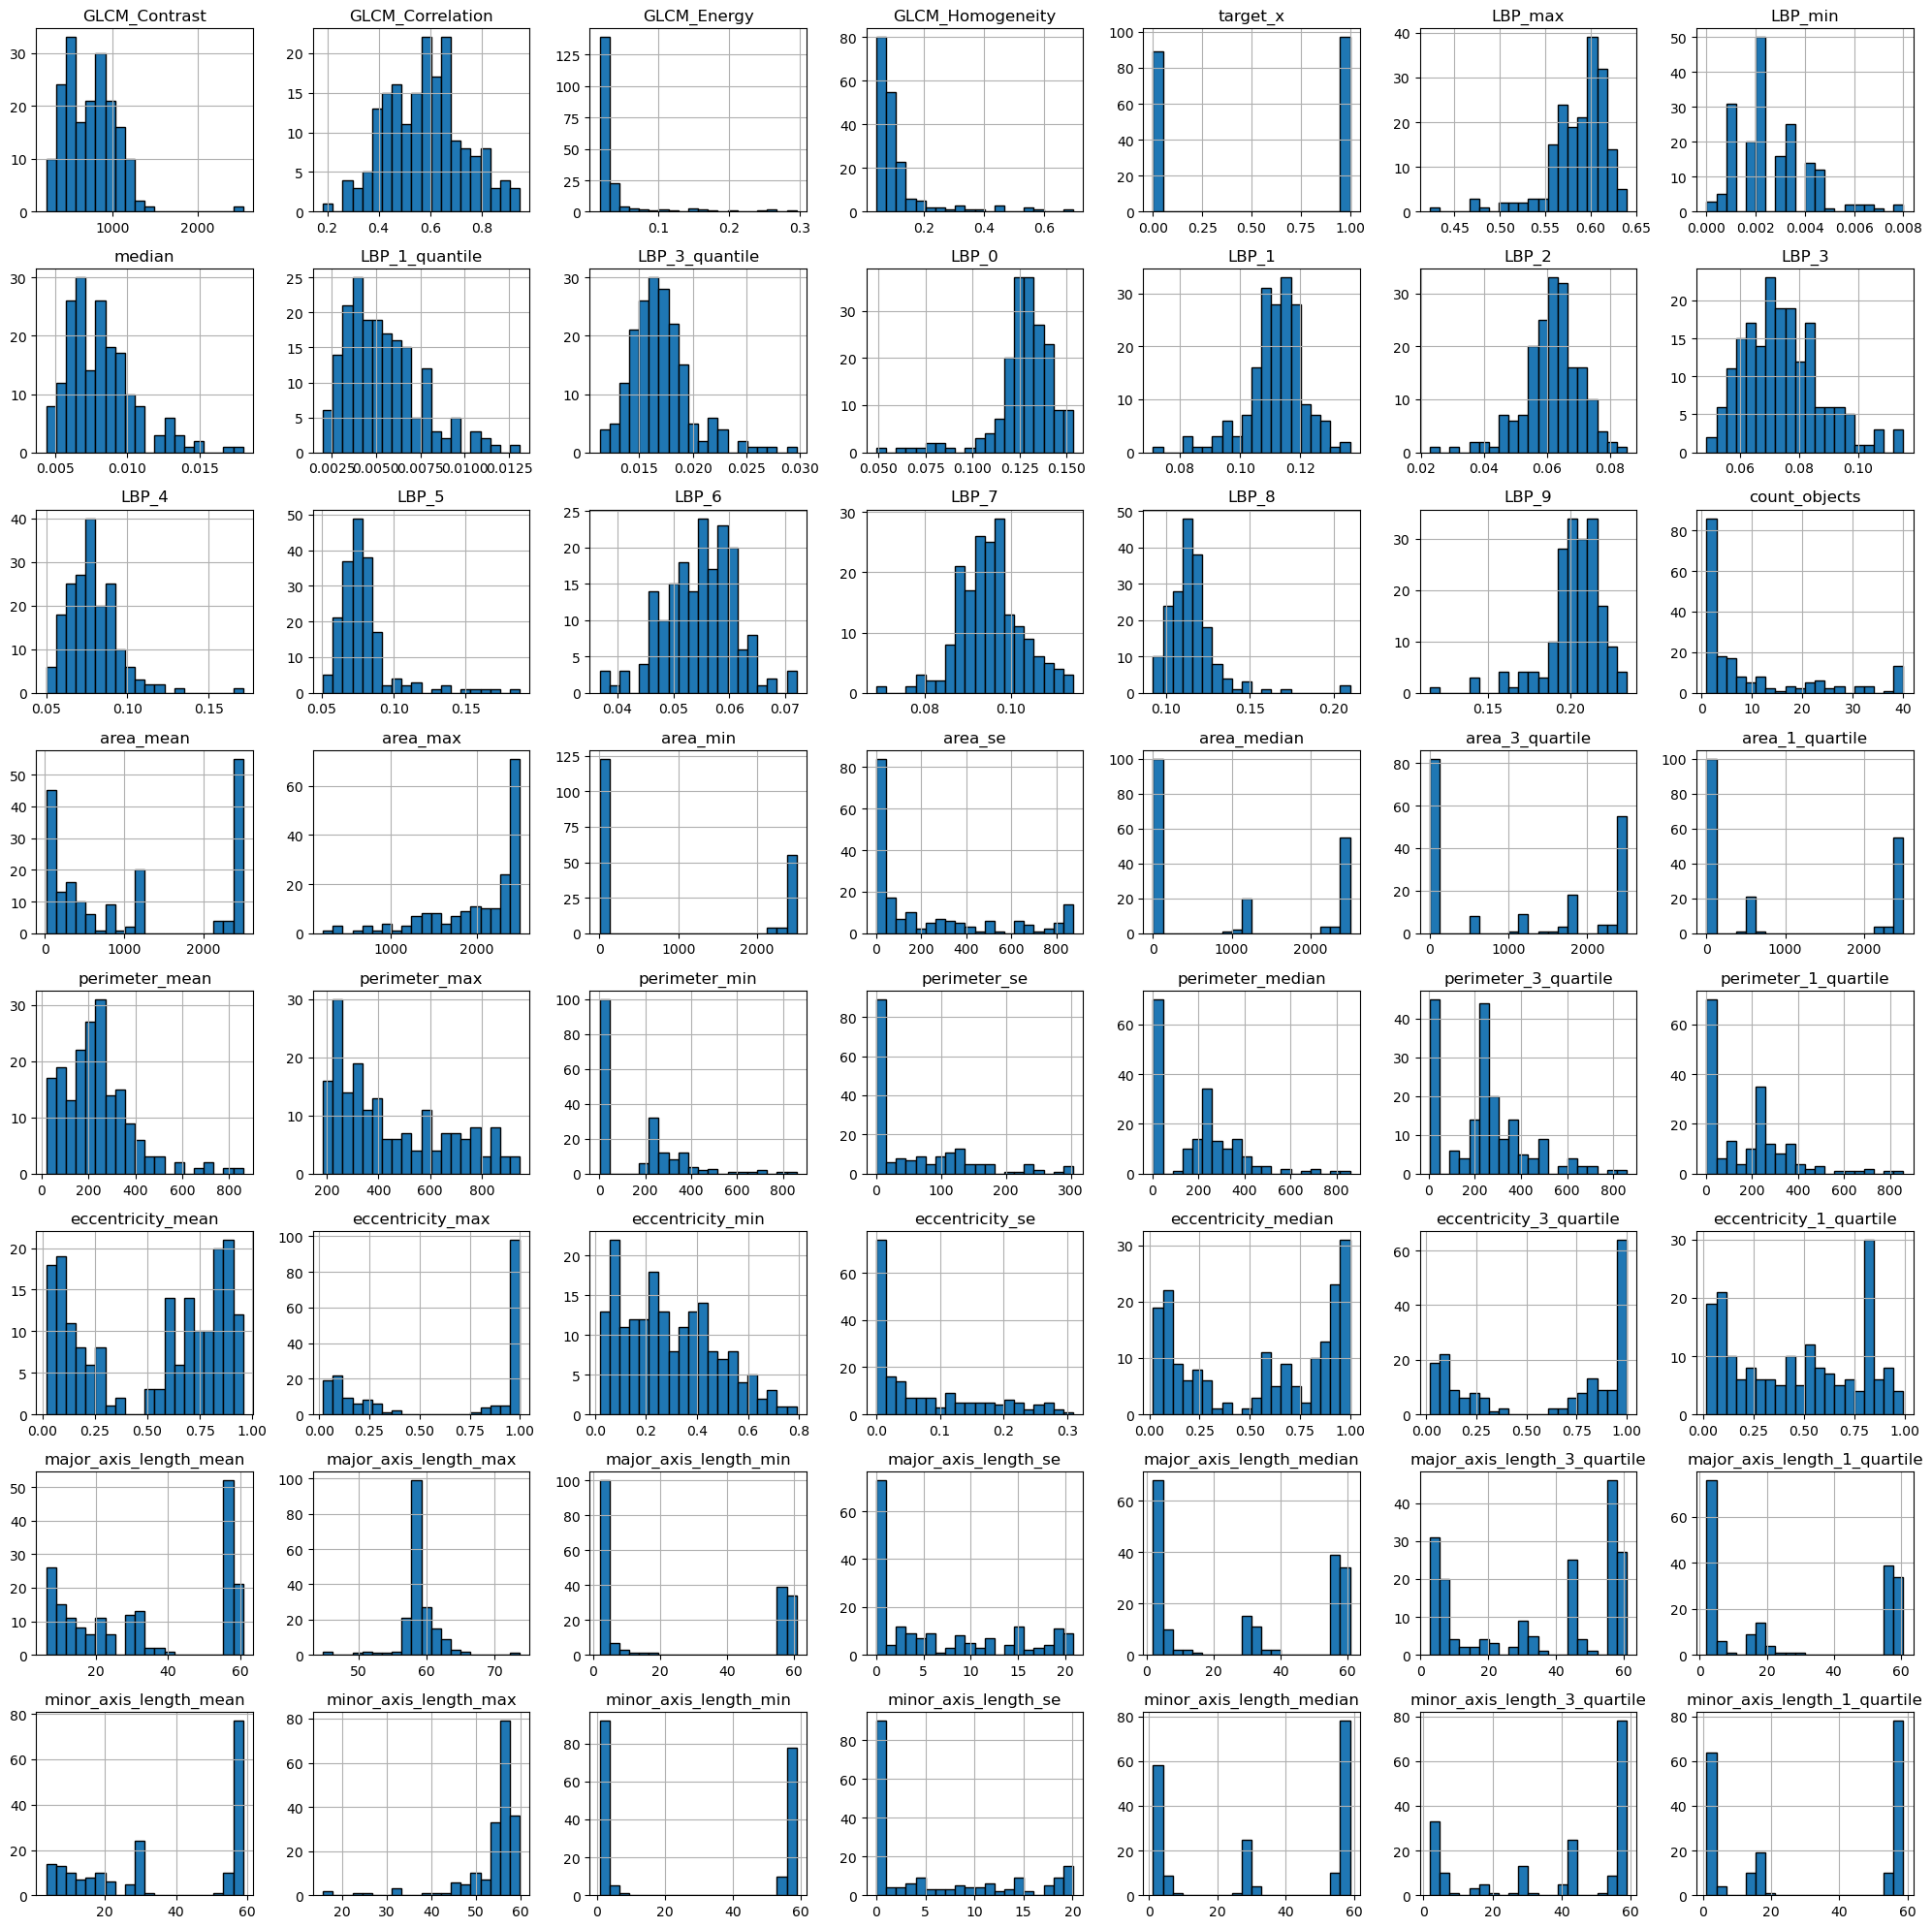

In [395]:
# Check distribution of values
final_df.hist(figsize=(20, 20), bins=20, edgecolor="black")
plt.tight_layout()
plt.show()

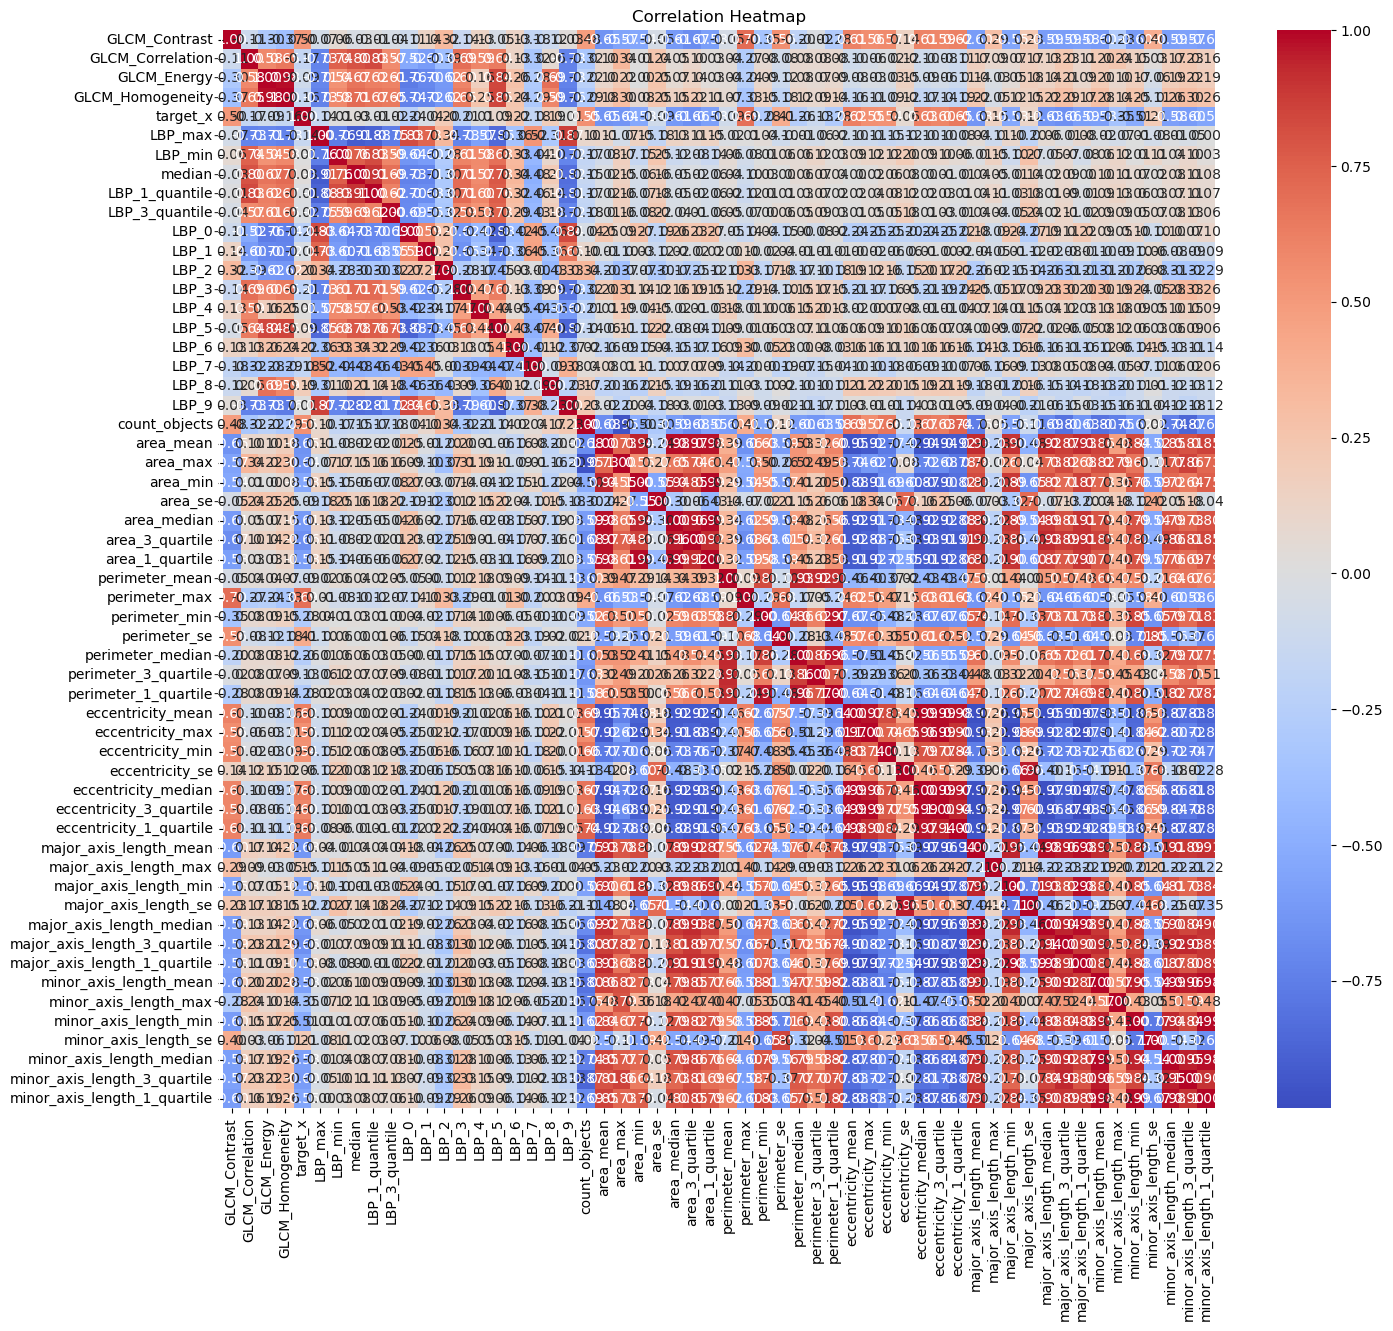

In [396]:
df_excluded = final_df.drop(columns=['Sample_ID_x'])
#num_cols = [cols for cols in df_excluded.columns if df_excluded[cols].dtype in ['int64', 'float64']]

correlation_matrix = df_excluded.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()



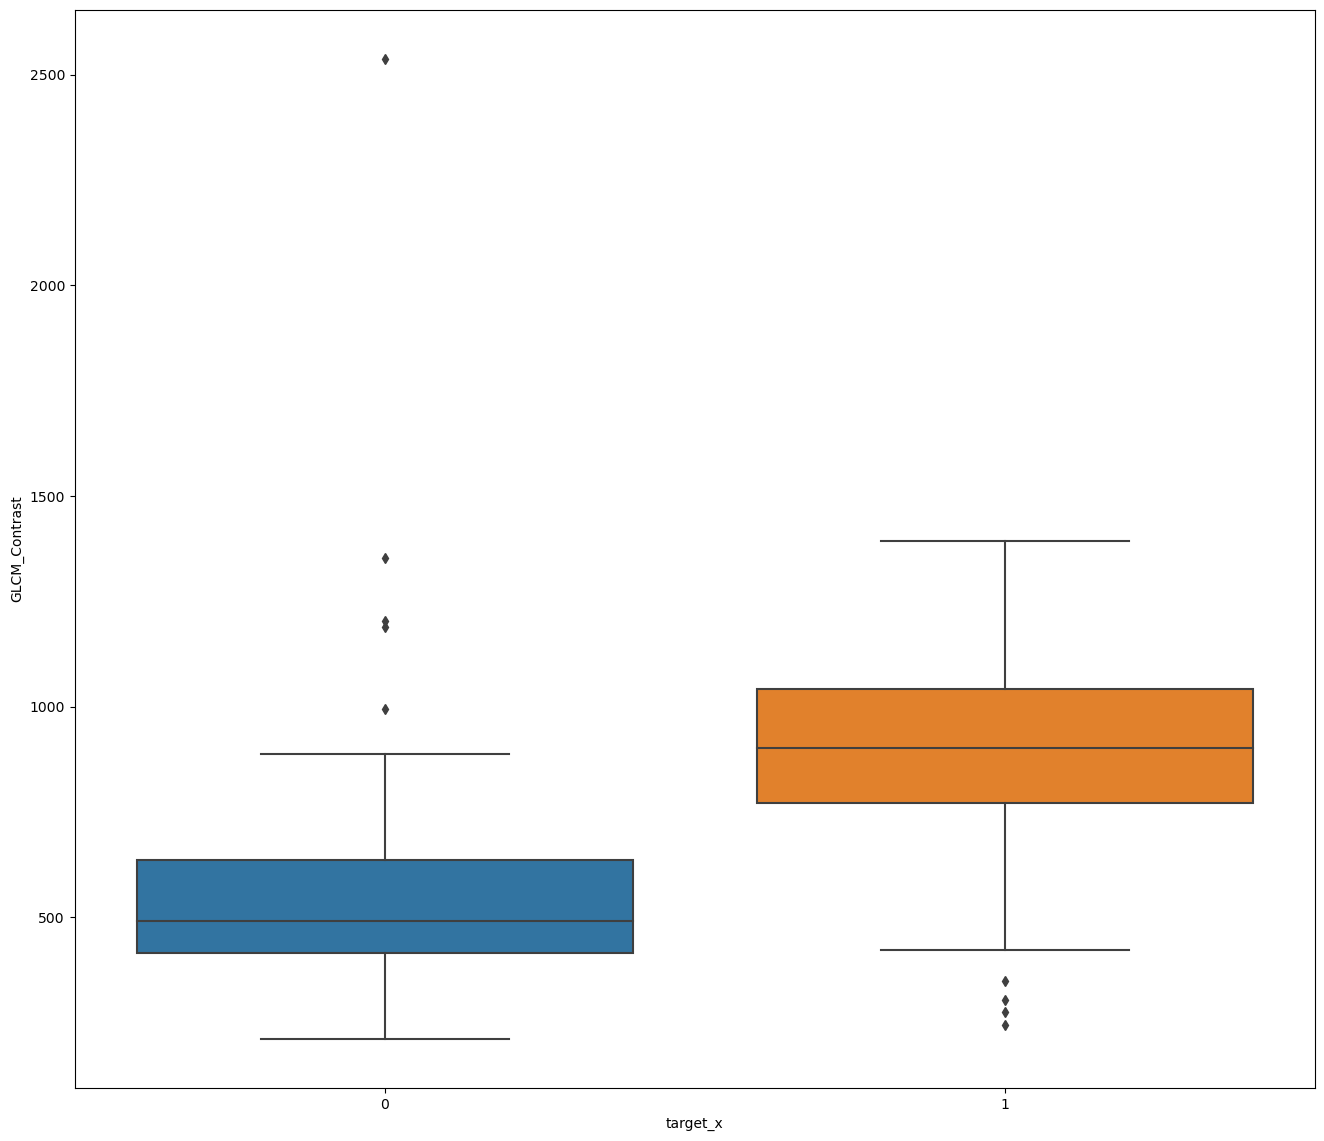

In [398]:

# Check distribution of values
plt.figure(figsize=(16,14))
sns.boxplot(data=df_excluded, x='target_x', y='GLCM_Contrast')

plt.show()

In [399]:

final_df.fillna(0, inplace=True)
# Step 4: Separate features (X) and target (y)
X = final_df.drop(columns=['target_x', 'Sample_ID_x'])  # Features
y = final_df['target_x']  # Target labels

# Step 5: Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=142, stratify=y)



# Step 6: Train the Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=142, max_depth=None, class_weight="balanced")
rf_model.fit(X_train, y_train)

# Step 7: Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]


In [400]:
# Step 8: Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.868421052631579

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86        18
           1       0.89      0.85      0.87        20

    accuracy                           0.87        38
   macro avg       0.87      0.87      0.87        38
weighted avg       0.87      0.87      0.87        38

ROC-AUC Score: 0.9347222222222222


[[16  2]
 [ 3 17]]


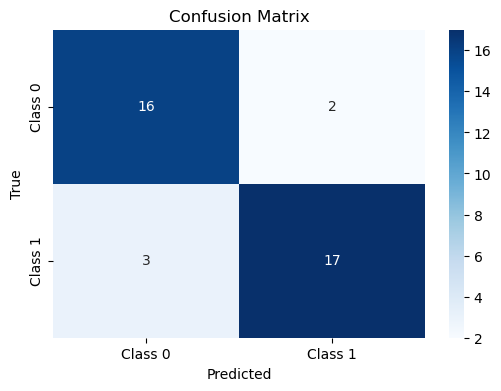

In [401]:
# Step 9: Generate a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

                         Feature  Importance
3               GLCM_Homogeneity    0.071379
2                    GLCM_Energy    0.055679
21                      area_max    0.055482
28                 perimeter_max    0.043698
25               area_3_quartile    0.039616
39       eccentricity_3_quartile    0.038076
43         major_axis_length_min    0.037270
47  major_axis_length_1_quartile    0.037249
50         minor_axis_length_min    0.028658
24                   area_median    0.026554
26               area_1_quartile    0.025942
20                     area_mean    0.025268
41        major_axis_length_mean    0.024366
35              eccentricity_max    0.024199
45      major_axis_length_median    0.021119
34             eccentricity_mean    0.020737
46  major_axis_length_3_quartile    0.020597
40       eccentricity_1_quartile    0.020234
27                perimeter_mean    0.019797
52      minor_axis_length_median    0.018337
22                      area_min    0.018108
18        

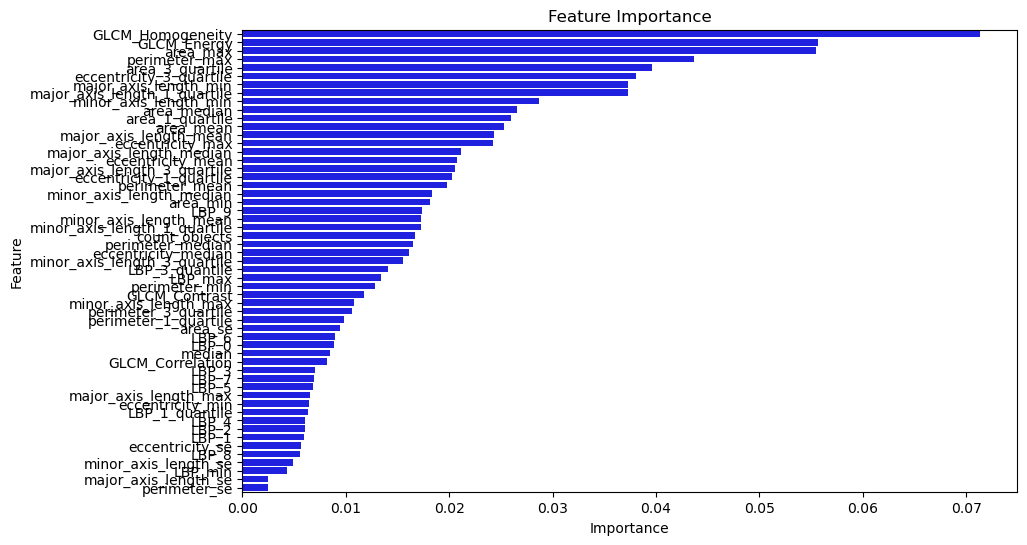

In [402]:
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print(feature_importances)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'], color='blue')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

In [39]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy: ", scores.mean())

Cross-Validation Accuracy:  1.0
